# Exploratory Data Analysis (EDA) - Viladecans

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Load the ML Dataset

In [2]:
# Load the Viladecans noise ML dataset
dataset = pd.read_csv("data/vil_noise_class_ml_dataset.csv")

print(f"Dataset shape: {dataset.shape}")
dataset.head()
print(dataset.columns.tolist())

Dataset shape: (1613, 22)
['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness400', 'straightness', 'green', 'industrial', 'commercial']


## Reduce the number of columns

In [3]:
print(dataset.columns.tolist())

['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness400', 'straightness', 'green', 'industrial', 'commercial']


<Axes: >

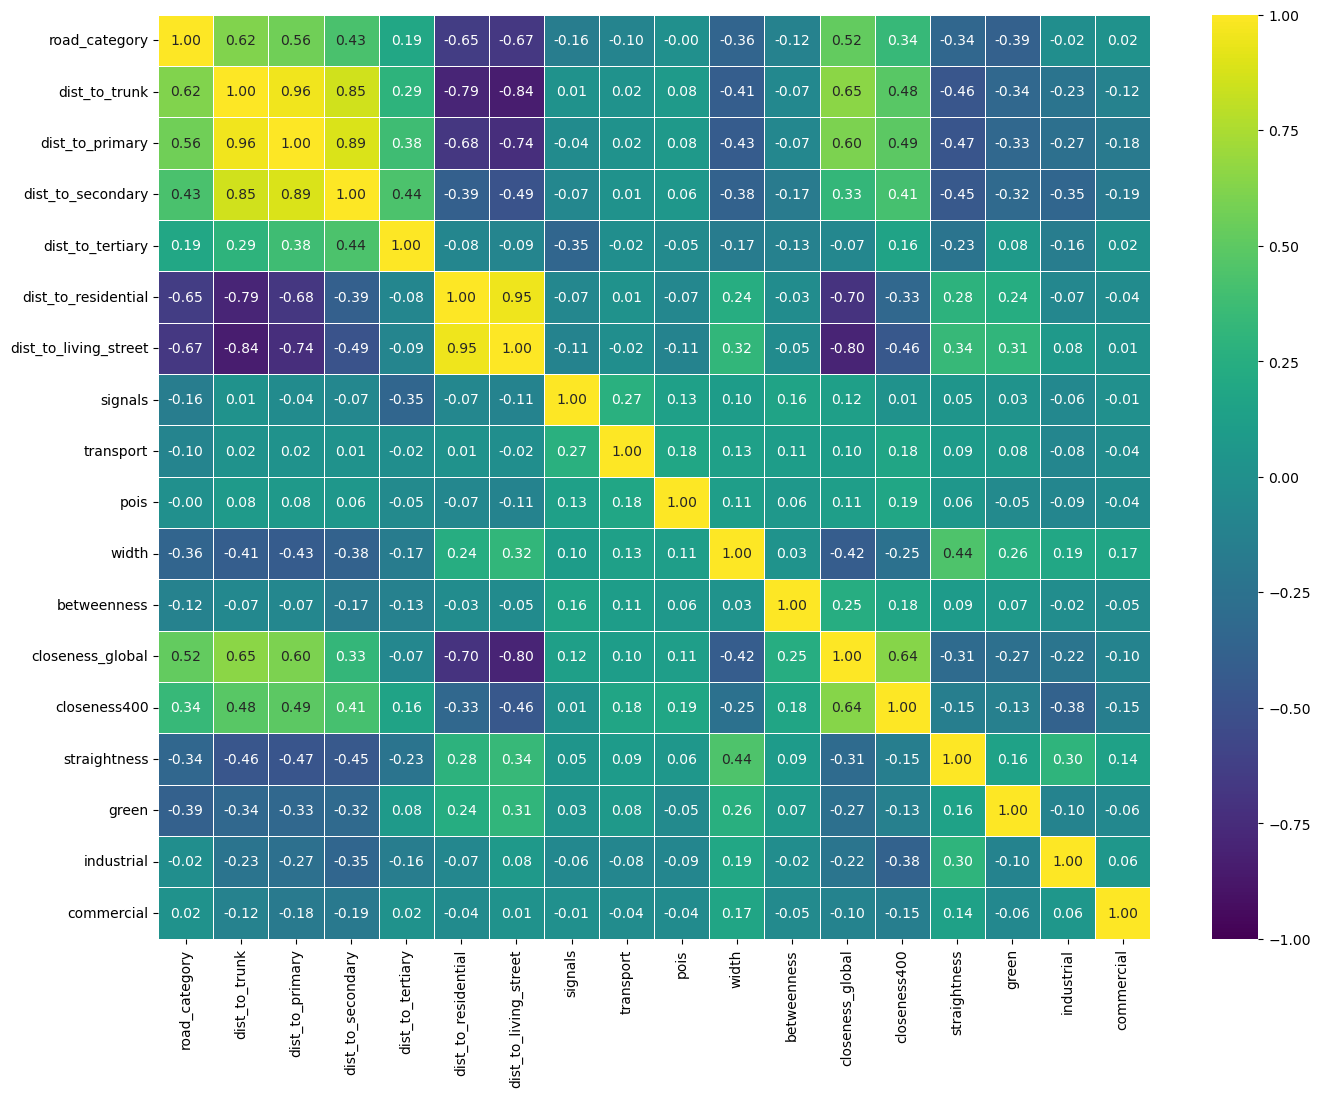

In [4]:
dataset_features = dataset.drop(columns=['road_id', 'noise_day', 'noise_evening', 'noise_night'])
plt.figure(figsize=(16, 12))
sns.heatmap(dataset_features.corr(), center=0, linewidths=0.5,
            cmap="viridis", vmin=-1, vmax=1, annot=True, fmt=".2f")

## Calculate Spearman correlation

Pearson measures linear relationships
-> very sensitive to outliers and nonlinear patterns

Spearman measures rank-order relationships
-> works well with nonlinear relationships and is more robust to outliers

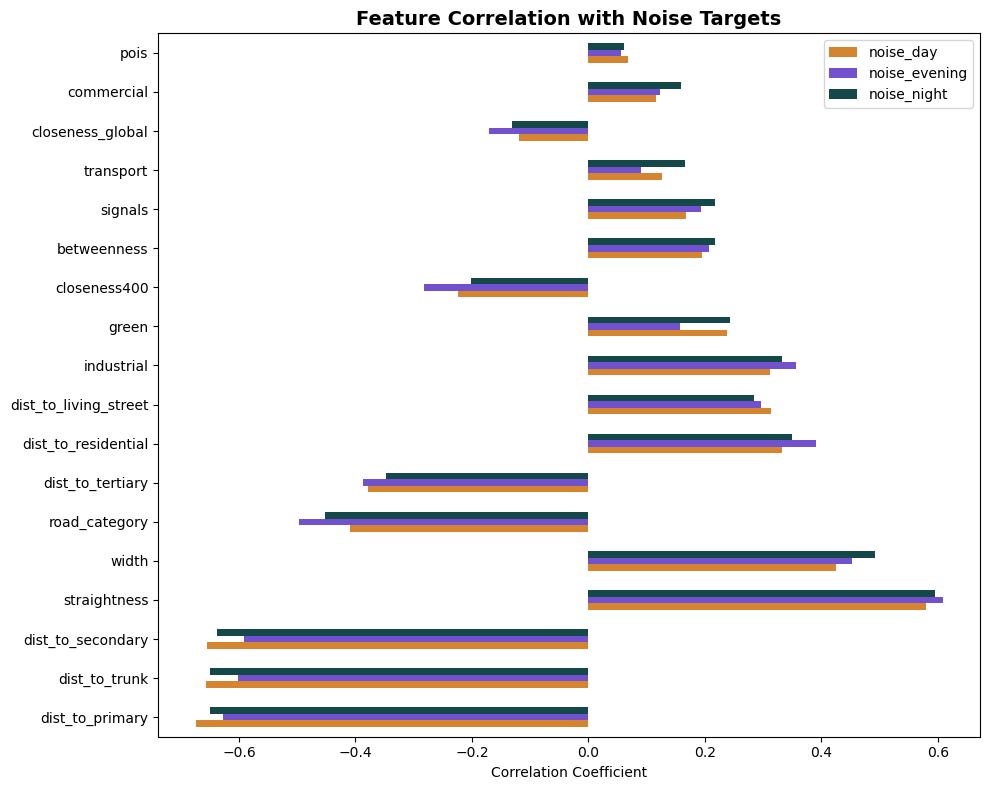

                       noise_day  noise_evening  noise_night
straightness            0.579191       0.608164     0.595347
width                   0.425670       0.452279     0.491225
dist_to_residential     0.332332       0.391213     0.348879
dist_to_living_street   0.312771       0.295496     0.284941
industrial              0.312507       0.356514     0.331566
green                   0.238580       0.157150     0.242930
betweenness             0.194611       0.207827     0.217098
signals                 0.167901       0.193490     0.217805
transport               0.126658       0.090816     0.166658
commercial              0.115209       0.123753     0.158154
pois                    0.067274       0.055675     0.061007
closeness_global       -0.119519      -0.170700    -0.131284
closeness400           -0.223101      -0.282732    -0.202292
dist_to_tertiary       -0.378471      -0.387402    -0.346734
road_category          -0.408691      -0.496676    -0.451723
dist_to_secondary      -

In [5]:
dataset_filtered = dataset.drop(columns=['road_id'])
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method='spearman')[target_cols].drop(target_cols)

feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(
    kind='barh', ax=ax, color=['#d58430', '#7251ce', '#144849'])
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

In [6]:
dataset_pairs = dataset.drop(columns=['road_id', 'noise_evening', 'noise_night'])

sample = dataset_pairs.sample(n=1000, random_state=42).copy()

sorted_noise_values = sorted(sample['noise_day'].unique())
sample['noise_day'] = pd.Categorical(sample['noise_day'], categories=sorted_noise_values, ordered=True)

In [7]:
print("Noise Day values:")
print(dataset['noise_day'].unique())
print("\nUnique values count:", dataset['noise_day'].nunique())

Noise Day values:
[3 4 2 1]

Unique values count: 4
